In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv
import os
load_dotenv()

C:\Users\Dell\AppData\Local\Temp\ipykernel_19988\3771868358.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


g:\Telegram Desktop\langGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("G:/Telegram Desktop/langGraph/advance_rag/book1.pdf").load()
    + PyPDFLoader("G:/Telegram Desktop/langGraph/advance_rag/book2.pdf").load()
    + PyPDFLoader("G:/Telegram Desktop/langGraph/advance_rag/book3.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")


In [4]:
api_key = os.getenv("GROQ_API_KEY")

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)

In [5]:
from langchain_community.embeddings import HuggingFaceEmbeddings
# This downloads a tiny ~90MB transformer model that runs for free on your CPU
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_19988\4010878894.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 275.60it/s]


In [6]:
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})


In [7]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [8]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [9]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [10]:
class KeepOrDrop(BaseModel):
    keep: bool

In [11]:
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

In [12]:
filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

In [21]:
def refine(state : State)-> State :

    q = state['question']

    context = '\n\n'.join(d.page_content for d in state['docs']).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({'question' : q, 'sentence' : s}).keep:
            kept.append(s)

    refined_context = '\n\n'.join(kept).strip()


    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }






In [22]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

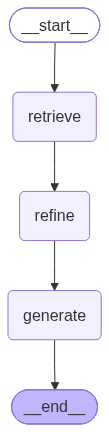

In [23]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [24]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

**Bias–variance trade‑off (as described in the provided material)**  

- The expected squared loss can be decomposed into three integrated terms:  

  \[
  \text{expected loss}= (\text{bias})^{2}+ \text{variance}+ \text{noise}
  \]  

  where  

  \[
  (\text{bias})^{2}= \int \bigl\{E_{D}[y(x;D)]-h(x)\bigr\}^{2}\,p(x)\,dx \tag{3.42}
  \]  

  \[
  \text{variance}= \int E_{D}\!\Bigl[\bigl\{y(x;D)-E_{D}[y(x;D)]\bigr\}^{2}\Bigr]\,p(x)\,dx \tag{3.43}
  \]  

  \[
  \text{noise}= \int \bigl\{h(x)-t\bigr\}^{2}\,p(x,t)\,dx\,dt \tag{3.44}
  \]

- **Bias** measures how far the average prediction (averaged over all possible training sets \(D\)) is from the true regression function \(h(x)\). A large bias means the model’s mean prediction is systematically off‑target.  

- **Variance** measures how much the predictions produced by different training sets fluctuate around their average. High variance indicates the model is very sensitive to the particular data set used for training.  

- **Noise** 

In [25]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

(bias)2 =
∫
{ED[y(x; D)] − h(x)}2p(x)dx (3.42)
variance =
∫
ED
[
{y(x; D) − ED[y(x; D)]}2]
p(x)dx (3.43)
noise =
∫
{h(x) − t}2p(x,t )dxdt (3.44)
and the bias and variance terms now refer to integrated quantities.
Our goal is to minimize the expected loss, which we have decomposed into the
sum of a (squared) bias, a variance, and a constant noise term. As we shall see, there
is a trade-off between bias and variance, with very ﬂexible models having low bias
and high variance, and relatively rigid models having high bias and low variance.
The model with the optimal predictive capability is the one that leads to the best
balance between bias and variance. This is illustrated by considering the sinusoidal
data set from Chapter 1. Here we generate 100 data sets, each containing N =2 5Appendix A
data points, independently from the sinusoidal curve h(x)=s i n ( 2πx). The data
****************************************************************************************************
squared bias, repr

In [26]:
from langchain_core.documents import Document

In [16]:
UPPER_TH = 0.7
LOWER_TH = 0.3


In [27]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str
    
    answer: str

In [28]:
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [29]:
class DocEvalScore(BaseModel):
    score: float
    reason: str

In [30]:
doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

In [31]:
doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


In [32]:
def eval_each_doc_node(state: State) -> State:

    q = state["question"]
    
    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score > LOWER_TH:
            good.append(d)

        # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

        

In [33]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


In [34]:
def refine(state: State) -> State:
    q = state["question"]

    # Combine retrieved docs into one context string
    # 5) In CORRECT case, eval node populates good_docs with docs having score > LOWER_TH
    context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [35]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}

In [36]:
def fail_node(state: State) -> State:
    return {"answer": f"FAIL: {state['reason']}"}

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

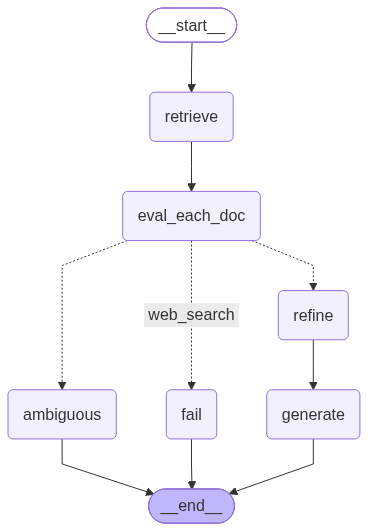

In [37]:
g = StateGraph(State)
g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("fail", fail_node)
g.add_node("ambiguous", ambiguous_node)


g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {"refine": "refine", "web_search": "fail", "ambiguous": "ambiguous"}
)
g.add_edge("refine", "generate")
g.add_edge("generate", END)
g.add_edge("fail", END)

app = g.compile()
app

In [41]:
res = app.invoke(
    {
        "question": "What are attention mechanisms and why are they important in current models?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 FAIL: All retrieved chunks scored < 0.3. No chunk was sufficient.


In [48]:
from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()


True

In [43]:
class State(TypedDict):

    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document]   # ✅ added
    
    answer: str

In [49]:
tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State) -> State:

    q = state["question"]  # no query rewrite
    results = tavily.invoke({"query": q})  # no knowledge selection

    web_docs = []
    for r in results or []:

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

In [54]:
from typing import List, Dict, Any

# 💡 FIX: Changed the return type hint from 'State' to 'dict' 
def eval_each_doc_node(state: State) -> dict:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        # 💡 PRO TIP: Add a try/except here if you still hit OpenAI parsing issues
        try:
            out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
            scores.append(out.score)
            
            if out.score > LOWER_TH:
                good.append(d)
        except Exception as e:
            # Fallback score if the model fails to output structured JSON
            scores.append(0.0)

    # Path 1: Clear winner found
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # Path 2: Everything failed completely
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # Path 3: Fallback / Mixed signals
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }


In [50]:
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()
    else:
        context = "\n\n".join(d.page_content for d in state["web_docs"]).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [51]:
def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

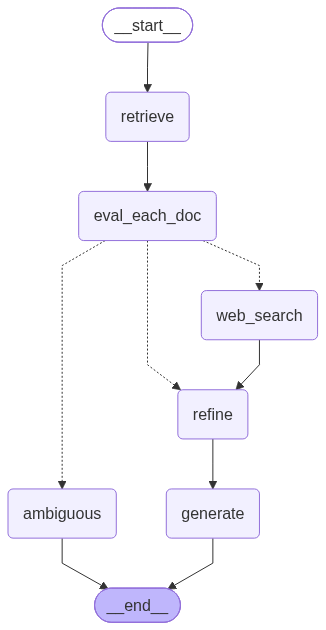

In [55]:
# -----------------------------
# Graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("web_search", web_search_node)
g.add_node("refine", refine)          # uses verdict to pick good_docs vs web_docs
g.add_node("generate", generate)
g.add_node("ambiguous", ambiguous_node)

# flow
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

# route after evaluation
g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",          # CORRECT -> refine (good_docs)
        "web_search": "web_search",  # INCORRECT -> web_search
        "ambiguous": "ambiguous",    # AMBIGUOUS -> end (your current choice)
    },
)

# ✅ key change: web_search now goes through refine
g.add_edge("web_search", "refine")    # INCORRECT -> refine (web_docs)
g.add_edge("refine", "generate")      # CORRECT/INCORRECT -> generate

g.add_edge("generate", END)
g.add_edge("ambiguous", END)

app = g.compile()
app

In [56]:
res = app.invoke(
    {
        "question": "AI news from the last month",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 **AI news highlights from roughly the last 30 days (late July – late August 2026)**  

---

### Platform‑level moves & governance  

- **LinkedIn** introduced a new “low‑quality AI output” flag and retired its “Enhance your post” writer, replacing it with a conservative proof‑reader that keeps the author’s voice. Flagged posts will be used to train detection models and will receive reduced reach. The site is already blocking **hundreds of thousands of automated comment attempts daily**, and detection firm **Pangram estimates >40 % of long‑form LinkedIn posts are fully AI‑generated**【AI Newsflash (July 27‑Aug 2)】.  

- **OpenAI, Anthropic, Google and Meta** (over 1,100 employees combined) signed the **“Pacing the Frontier”** open letter urging the U.S. government to back an international effort that creates technical and governance tools for deliberately slowing the rate of automated AI deve

In [57]:
class State(TypedDict):

    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document]

    web_query: str          # ✅ NEW
    
    answer: str

In [58]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

In [59]:
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "rewrite_query"   # ✅ changed
    else:
        return "ambiguous"

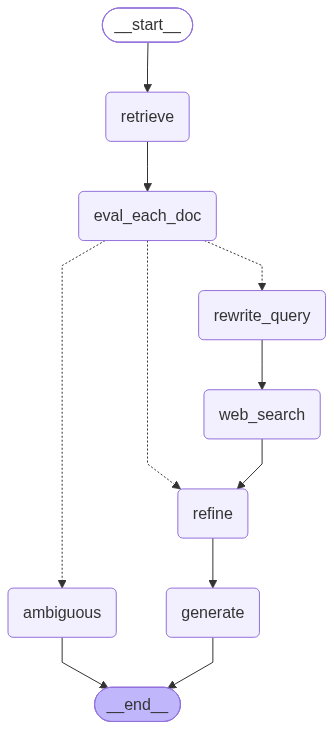

In [60]:
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)  # ✅ NEW
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",  # ✅ NEW branch
        "ambiguous": "ambiguous",
    },
)

# INCORRECT path: rewrite -> web_search -> refine -> generate
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")
g.add_edge("refine", "generate")

g.add_edge("generate", END)
g.add_edge("ambiguous", END)

app = g.compile()

app

In [61]:
res = app.invoke(
    {
        "question": "Recent AI news",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 **Recent AI News (July – August 2026)**  

---

### 1. Enterprise‑focused AI updates  
- **Okta** – Introduced “MCP scoping” to curb AI‑agent token costs for its customers (Aug 18 2026).  
- **Google Gemini 3.6 Flash** – Launched a version aimed at reducing token expenses for enterprise agents (Jul 21 2026).  
- **Red Hat, NVIDIA & IBM** – Joined a joint project that turns AI policy statements into executable code, improving governance and compliance (Aug 13 2026).  

### 2. Agentic AI in business applications  
- **HoneyBook** – Added a Claude‑based connector to automate small‑business workflows with agentic AI (Aug 6 2026).  
- **Meta (Zuckerberg)** – Outlined a “personal AI superintelligence” strategy for individualized user experiences (Jul 30 2026).  

### 3. AI for security and fraud prevention  
- **Aviva** – Deployed AI tools that have already stopped roughly **£230 M** in sophistic

In [62]:
res['web_query']

'latest artificial intelligence news last 30 days'

In [63]:
res = app.invoke(
    {
        "question": "Recent AI news and what is gradient decent with 100 words",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3. Mixed relevance signals.

OUTPUT:
 Ambiguous: No chunk scored > 0.7, but not all were < 0.3. Mixed relevance signals.


In [64]:
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:  # AMBIGUOUS
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }




In [65]:
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"

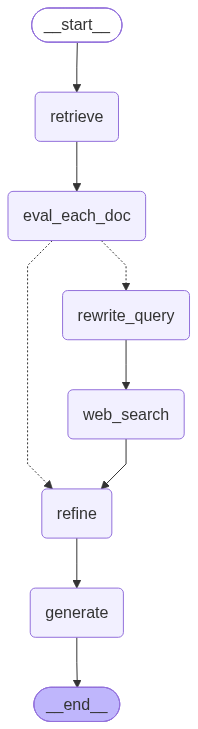

In [66]:
# -----------------------------
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [67]:
res = app.invoke(
    {
        "question": "Recent AI news and what is gradient decent with 100 words",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3. Mixed relevance signals.

OUTPUT:
 April 2026 AI news highlights Google’s eighth‑generation TPUs built for the agentic era, offering massive compute with better energy efficiency. Google Vids now lets any account generate up to ten AI‑crafted videos per month for free, while the Gemini Enterprise Agent Platform enables firms to build and manage custom AI agents. New releases such as Gemini 4, Deep Research Max, and Colab’s Learn Mode turn Gemini into a personal coding tutor. Gradient descent is an iterative optimization algorithm that reduces a model’s loss by repeatedly moving parameters opposite the gradient—the steepest slope—using a small learning‑rate step until the error minimum is reached.
